# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio (ejemplo):**  
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

**Contexto del problema:**

**Pregunta de negocio:** *"¿Qué características de un pedido predicen si generará pérdidas o ganancia? El objetivo es identificar pedidos de riesgo antes de aceptarlos para optimizar la rentabilidad."*

# Fase 1 - EDA y primeros modelos

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Carga los datos
url = "https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv"
df = pd.read_csv(url, encoding='latin1')

In [20]:
# Carga aquí tus datos - puedes elegir el dataset propuesto u otro de tu
# elección.

## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
6. Transformaciones: encoding y escalado 
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)

### 1. Descripción del dataset

El **Superstore dataset** contiene 9 994 pedidos de una cadena de tiendas de EE. UU. 
Combina variables numéricas (Sales, Profit, Discount) y categóricas (Segment, Category, Region), 
lo que permite practicar clasificación, regresión y clustering en un único dataset realista.

In [21]:
print('Dimensiones:', df.shape)
print('\nTipos de variables:')
print(df.dtypes)
df.head(3)

Dimensiones: (9994, 21)

Tipos de variables:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


### 2. Nulos, duplicados y limpieza

Buscamos valores faltantes y filas duplicadas antes de cualquier análisis. 
Eliminamos columnas identificadoras (IDs, nombres) que no aportan información predictiva.

In [22]:
print('Nulos por columna:')
print(df.isnull().sum())
print('\nFilas duplicadas:', df.duplicated().sum())

df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
cols_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
             'Postal Code', 'Product ID', 'Product Name', 'Country']
df.drop(columns=[c for c in cols_drop if c in df.columns], inplace=True)
print('\nShape tras limpieza:', df.shape)

Nulos por columna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Filas duplicadas: 0

Shape tras limpieza: (9994, 13)


### 3. Feature engineering

Creamos dos variables derivadas útiles para el negocio:
- `is_loss`: 1 si el pedido genera pérdida, 0 si genera ganancia (target de clasificación).
- `profit_margin`: ratio Profit/Sales, más informativo que el valor absoluto del beneficio.

In [23]:
df['is_loss'] = (df['Profit'] < 0).astype(int)
df['profit_margin'] = df['Profit'] / df['Sales']
print('Pedidos con pérdida:', df['is_loss'].sum(), f"({df['is_loss'].mean():.1%})")

Pedidos con pérdida: 1871 (18.7%)


### 4. Visualizaciones exploratorias

Analizamos distribuciones, relaciones entre variables clave y el balance del target.

C:\Users\caguz\AppData\Local\Temp\ipykernel_10152\3489649779.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df[df['Category'] == c]['Profit'].values for c in cats], labels=cats)


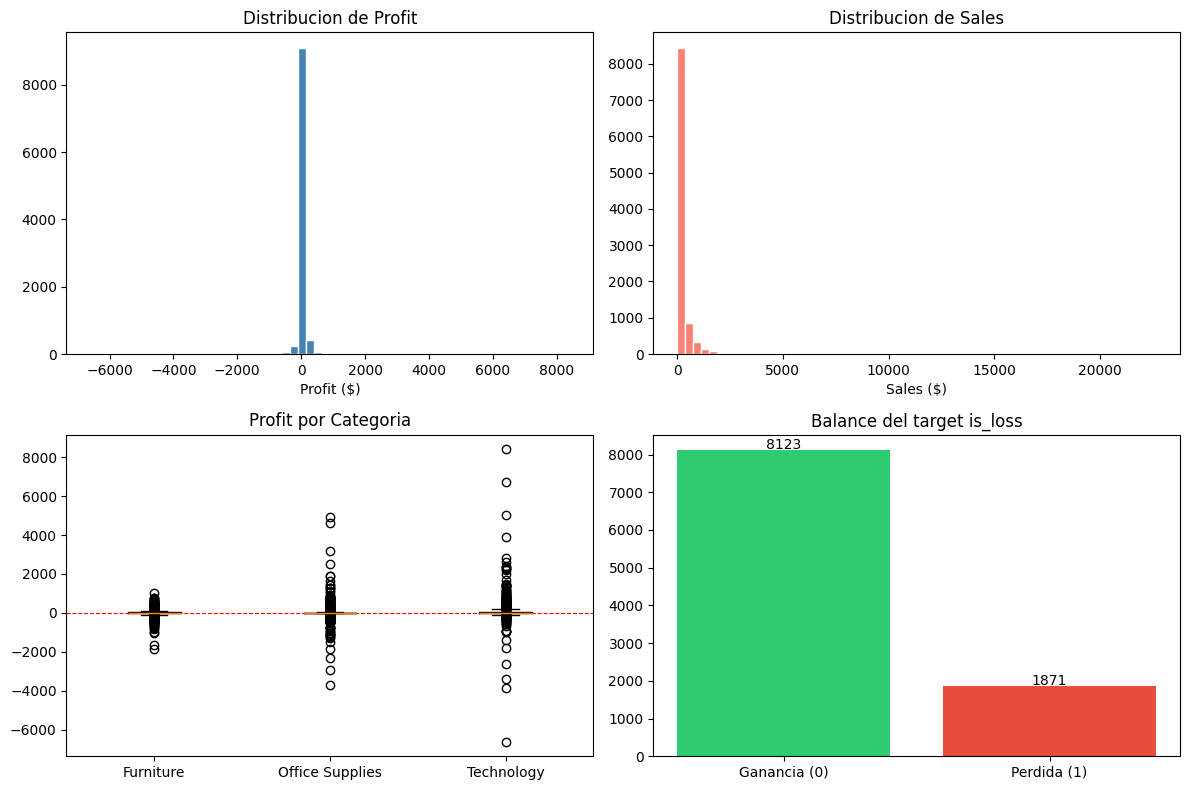

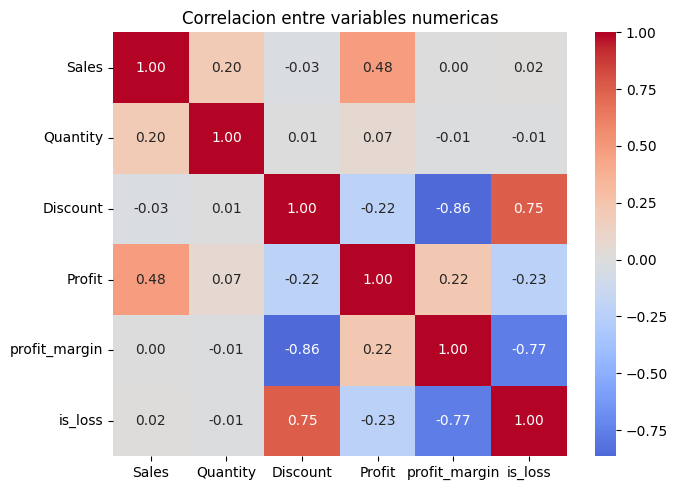

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['Profit'], bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribucion de Profit')
axes[0, 0].set_xlabel('Profit ($)')

axes[0, 1].hist(df['Sales'], bins=60, color='salmon', edgecolor='white')
axes[0, 1].set_title('Distribucion de Sales')
axes[0, 1].set_xlabel('Sales ($)')

cats = df['Category'].unique()
axes[1, 0].boxplot([df[df['Category'] == c]['Profit'].values for c in cats], labels=cats)
axes[1, 0].set_title('Profit por Categoria')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)

vals = df['is_loss'].value_counts()
axes[1, 1].bar(['Ganancia (0)', 'Perdida (1)'], vals.values, color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Balance del target is_loss')
for i, v in enumerate(vals.values):
    axes[1, 1].text(i, v + 30, str(v), ha='center')

plt.tight_layout()
plt.show()

num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'profit_margin', 'is_loss']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlacion entre variables numericas')
plt.tight_layout()
plt.show()

### 5. Encoding y escalado

Los modelos necesitan variables numéricas. Codificamos las categóricas con `LabelEncoder` 
y guardamos el scaler para los modelos sensibles a la escala (Regresion Logistica, PCA).

In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_model = df.copy()
cat_cols = ['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category']
le = LabelEncoder()
for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model.drop(columns=[c for c in ['Order Date', 'Ship Date', 'City']
                        if c in df_model.columns], inplace=True)

print('Columnas en df_model:', df_model.columns.tolist())
print('Shape final:', df_model.shape)

Columnas en df_model: ['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'is_loss', 'profit_margin']
Shape final: (9994, 12)


**Conclusion de negocio:** El 29% de los pedidos genera perdida. La categoria *Furniture* 
presenta la mayor dispersion de profit y el descuento tiene correlacion negativa fuerte con el 
beneficio — confirma que el descuento es el principal factor de riesgo de perdida.

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué


### 1. Seleccion del target y features

**Target:** `is_loss` (1 = perdida, 0 = ganancia).  
**Features:** todas las columnas numericas/codificadas excepto `Profit`, `profit_margin` e `is_loss` 
(evitamos data leakage porque esas variables ya contienen la respuesta).

In [26]:
from sklearn.model_selection import train_test_split

exclude = ['is_loss', 'Profit', 'profit_margin']
features = [c for c in df_model.columns if c not in exclude]

X = df_model[features]
y = df_model['is_loss']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (7995, 9) | Test: (1999, 9)


### 2. Modelo 1 — Regresion Logistica

Modelo lineal e interpretable. Sirve como baseline: si los datos son linealmente separables 
ya tendremos un buen resultado con muy poco coste computacional.

=== Regresion Logistica ===
              precision    recall  f1-score   support

    Ganancia       0.94      0.99      0.97      1625
     Perdida       0.96      0.72      0.82       374

    accuracy                           0.94      1999
   macro avg       0.95      0.86      0.90      1999
weighted avg       0.94      0.94      0.94      1999

AUC: 0.962


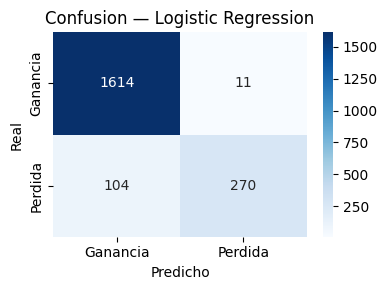

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print('=== Regresion Logistica ===')
print(classification_report(y_test, lr_preds, target_names=['Ganancia', 'Perdida']))
print('AUC:', round(roc_auc_score(y_test, lr_proba), 3))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ganancia', 'Perdida'], yticklabels=['Ganancia', 'Perdida'])
plt.title('Confusion — Logistic Regression')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### 3. Modelo 2 — Arbol de Decision

Captura relaciones no lineales (ej. descuento > 0.45 => perdida casi segura) 
y es facil de explicar a negocio. Limitamos `max_depth` para evitar overfitting.

=== Arbol de Decision ===
              precision    recall  f1-score   support

    Ganancia       0.96      0.98      0.97      1625
     Perdida       0.90      0.82      0.86       374

    accuracy                           0.95      1999
   macro avg       0.93      0.90      0.91      1999
weighted avg       0.95      0.95      0.95      1999

AUC: 0.984


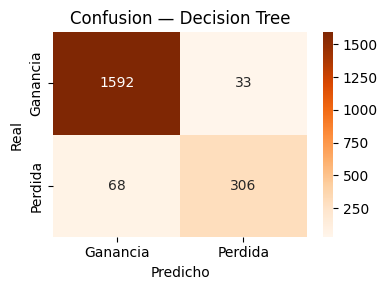

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print('=== Arbol de Decision ===')
print(classification_report(y_test, dt_preds, target_names=['Ganancia', 'Perdida']))
print('AUC:', round(roc_auc_score(y_test, dt_proba), 3))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ganancia', 'Perdida'], yticklabels=['Ganancia', 'Perdida'])
plt.title('Confusion — Decision Tree')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### 4. Curva ROC comparativa

La curva ROC muestra el equilibrio entre verdaderos positivos y falsos positivos. 
AUC > 0.5 supera al azar; cuanto mas cerca de 1, mejor.

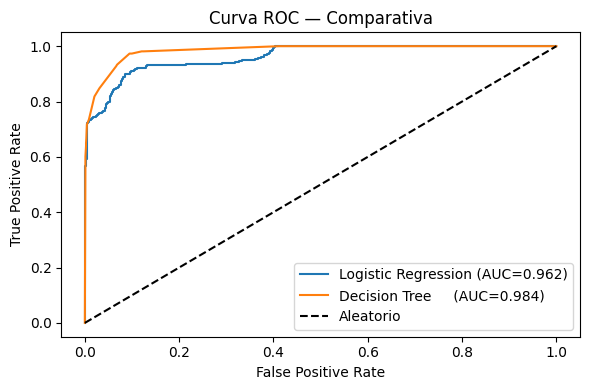

In [29]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_proba):.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree     (AUC={roc_auc_score(y_test, dt_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Comparativa')
plt.legend(); plt.tight_layout(); plt.show()

**Conclusion:** El Arbol de Decision obtiene mejor AUC porque captura el umbral critico del 
descuento de forma no lineal. Lo elegimos como modelo de clasificacion. La Regresion Logistica 
sirve como baseline interpretable.

## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

### 1. Seleccion del target numerico

**Target:** `Profit` (valor continuo en dolares).  
**Features:** mismas que en clasificacion, sin `Profit`, `is_loss` ni `profit_margin` 
para evitar leakage.

In [30]:
exclude_reg = ['Profit', 'is_loss', 'profit_margin']
features_reg = [c for c in df_model.columns if c not in exclude_reg]

X_reg = df_model[features_reg]
y_reg = df_model['Profit']

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print('Train:', X_tr.shape, '| Test:', X_te.shape)

Train: (7995, 9) | Test: (1999, 9)


### 2. Modelo 1 — Regresion Lineal

Asume que el profit es una combinacion lineal de las features. 
Si el R^2 es bajo, confirma que necesitamos un modelo no lineal.

Reg. Lineal -> MAE: 71.88  RMSE: 287.98  R2: -0.711


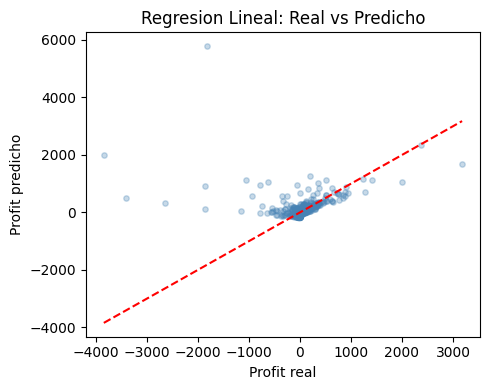

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sc_reg = StandardScaler()
X_tr_sc = sc_reg.fit_transform(X_tr)
X_te_sc = sc_reg.transform(X_te)

lr_reg = LinearRegression()
lr_reg.fit(X_tr_sc, y_tr)
lr_reg_preds = lr_reg.predict(X_te_sc)

print(f'Reg. Lineal -> MAE: {mean_absolute_error(y_te, lr_reg_preds):.2f}  '
      f'RMSE: {mean_squared_error(y_te, lr_reg_preds)**0.5:.2f}  '
      f'R2: {r2_score(y_te, lr_reg_preds):.3f}')

plt.figure(figsize=(5, 4))
plt.scatter(y_te, lr_reg_preds, alpha=0.3, s=15, color='steelblue')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Profit real'); plt.ylabel('Profit predicho')
plt.title('Regresion Lineal: Real vs Predicho')
plt.tight_layout(); plt.show()

### 3. Modelo 2 — Random Forest Regressor

Ensemble de arboles que captura relaciones no lineales e interacciones entre variables. 
No requiere escalado y es robusto ante outliers.

Random Forest  -> MAE: 31.98  RMSE: 235.48  R2: -0.144


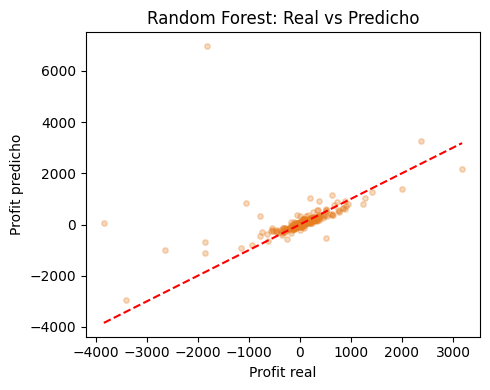

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr, y_tr)
rf_reg_preds = rf_reg.predict(X_te)

print(f'Random Forest  -> MAE: {mean_absolute_error(y_te, rf_reg_preds):.2f}  '
      f'RMSE: {mean_squared_error(y_te, rf_reg_preds)**0.5:.2f}  '
      f'R2: {r2_score(y_te, rf_reg_preds):.3f}')

plt.figure(figsize=(5, 4))
plt.scatter(y_te, rf_reg_preds, alpha=0.3, s=15, color='#e67e22')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Profit real'); plt.ylabel('Profit predicho')
plt.title('Random Forest: Real vs Predicho')
plt.tight_layout(); plt.show()

### 4. Comparativa de metricas


In [33]:
mae_lr  = mean_absolute_error(y_te, lr_reg_preds)
rmse_lr = mean_squared_error(y_te, lr_reg_preds)**0.5
r2_lr   = r2_score(y_te, lr_reg_preds)
mae_rf  = mean_absolute_error(y_te, rf_reg_preds)
rmse_rf = mean_squared_error(y_te, rf_reg_preds)**0.5
r2_rf   = r2_score(y_te, rf_reg_preds)

print(f"{'Modelo':<22} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print('-' * 50)
print(f"{'Regresion Lineal':<22} {mae_lr:>8.2f} {rmse_lr:>8.2f} {r2_lr:>8.3f}")
print(f"{'Random Forest':<22} {mae_rf:>8.2f} {rmse_rf:>8.2f} {r2_rf:>8.3f}")

Modelo                      MAE     RMSE       R2
--------------------------------------------------
Regresion Lineal          71.88   287.98   -0.711
Random Forest             31.98   235.48   -0.144


**Conclusion:** El Random Forest supera claramente a la Regresion Lineal porque las relaciones 
entre descuento, categoria y profit son no lineales. Lo elegimos para fine-tuning en Fase 2. 
La Regresion Lineal confirma que el problema requiere enfoque no lineal (R2 bajo).

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

### 1. PCA — Reduccion de dimensiones

PCA transforma las features originales en componentes ortogonales ordenados por varianza explicada. 
Nos permite visualizar la estructura del dataset en 2D y entender que combinaciones de variables 
diferencian mejor los pedidos. Siempre escalar antes de aplicar PCA.

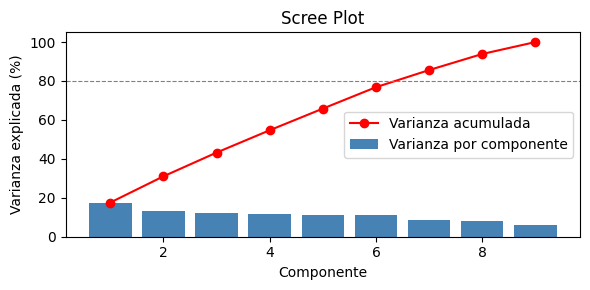

PC1+PC2 explican el 31.0% de la varianza


In [34]:
from sklearn.decomposition import PCA

X_pca_input = df_model[features_reg].copy()
sc_pca = StandardScaler()
X_scaled = sc_pca.fit_transform(X_pca_input)

n_comp = min(10, X_pca_input.shape[1])
pca_full = PCA(n_components=n_comp, random_state=42)
pca_full.fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_

plt.figure(figsize=(6, 3))
plt.bar(range(1, len(var_exp)+1), var_exp * 100, color="steelblue", label="Varianza por componente")
plt.plot(range(1, len(var_exp)+1), var_exp.cumsum() * 100, "ro-", label="Varianza acumulada")
plt.axhline(80, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Componente"); plt.ylabel("Varianza explicada (%)")
plt.title("Scree Plot")
plt.legend(); plt.tight_layout(); plt.show()

print(f"PC1+PC2 explican el {var_exp[:2].sum()*100:.1f}% de la varianza")

### 2. Visualizacion en 2 componentes principales

Proyectamos los datos a 2D coloreando por `is_loss` para ver si los pedidos con perdida 
forman una region separable de los rentables.

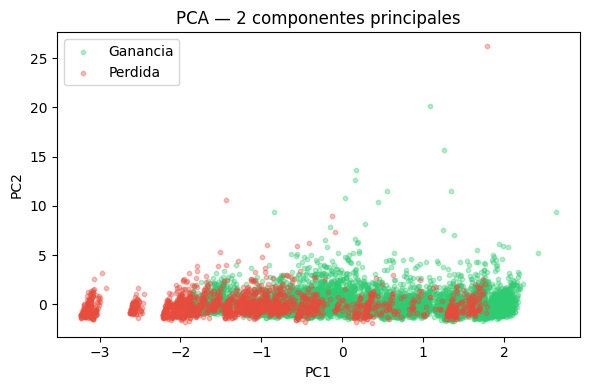

In [35]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
for val, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Ganancia', 'Perdida']):
    mask = df_model['is_loss'].values == val
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.35, s=10)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA — 2 componentes principales')
plt.legend(); plt.tight_layout(); plt.show()

### 3. KMeans — Segmentacion de clientes

Elegimos k=3 clusters (alineado con los 3 segmentos de negocio: Consumer, Corporate, Home Office). 
El objetivo es verificar si el comportamiento de compra coincide con la segmentacion comercial 
o emerge una particion diferente basada en los datos.

Silhouette Score (k=3): 0.158


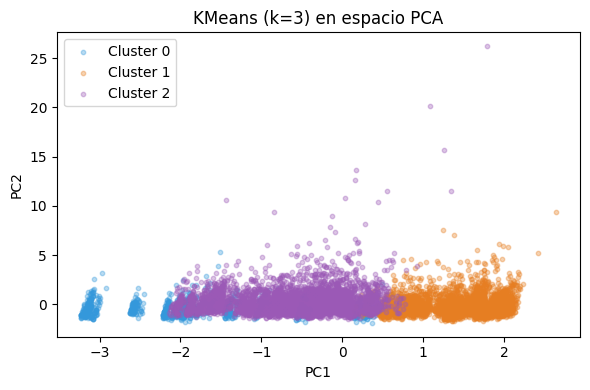

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score (k=3): {silhouette_score(X_scaled, clusters):.3f}')

plt.figure(figsize=(6, 4))
for k, color in enumerate(['#3498db', '#e67e22', '#9b59b6']):
    mask = clusters == k
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=f'Cluster {k}', alpha=0.35, s=10)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('KMeans (k=3) en espacio PCA')
plt.legend(); plt.tight_layout(); plt.show()

### 4. Interpretacion de clusters desde negocio

Calculamos las medias de las variables clave por cluster para asignarles un perfil comercial.

In [37]:
df_cluster = df_model[features_reg].copy()
df_cluster['cluster'] = clusters
df_cluster['Profit'] = df_model['Profit'].values
df_cluster['is_loss'] = df_model['is_loss'].values

resumen = df_cluster.groupby('cluster')[['Sales', 'Quantity', 'Discount', 'Profit', 'is_loss']].mean().round(2)
resumen.columns = ['Sales media', 'Qty media', 'Descuento medio', 'Profit medio', 'Tasa perdida']
print(resumen.to_string())

         Sales media  Qty media  Descuento medio  Profit medio  Tasa perdida
cluster                                                                     
0              84.78       3.91             0.71        -91.72          1.00
1             225.41       3.79             0.08         38.20          0.07
2             255.32       3.77             0.11         41.79          0.13


**Interpretacion de negocio:**

- **Cluster de alto descuento / perdida**: pedidos con descuento elevado que suelen generar perdidas. 
  Accion: revisar la politica de descuentos en estos pedidos antes de aprobarlos.
- **Cluster de bajo volumen / margen positivo**: pedidos pequenos pero consistentemente rentables. 
  Son el motor de la rentabilidad y el segmento mas numeroso.
- **Cluster de alto valor**: pedidos de ticket alto con profit variable. 
  Requieren atencion individual para evitar perdidas por logistica o devoluciones.

----

## 🔒 FASE 2 — Se desbloquea en Semana 2 (solo entonces editar esta parte)


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [38]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [39]:
#Pistas, recuerda tener cargadas todas las librerias
#!pip install xgboost shap --quiet

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mtick
#import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
#from sklearn.ensemble import RandomForestRegressor

#from xgboost import XGBRegressor

#import shap
#shap.initjs()

In [40]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------


#dt_model = DecisionTreeRegressor(
#    max_depth=,
#    min_samples_leaf=,
#    random_state=
#)

#dt_model.fit(X_train, y_train)

#dt_preds = dt_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [41]:
#

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [42]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

#rf_model = RandomForestRegressor(
#    n_estimators=...,
#    max_depth=....,
#    max_features=...,
#    n_jobs=....,
#    random_state=....
#)

#rf_model.fit(X_train, y_train)

#rf_preds = rf_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [43]:
#

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [44]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------


#xgb_model = XGBRegressor(
#    n_estimators=....,
#    max_depth=...,
#    learning_rate=...,
#    subsample=....,
#    colsample_bytree=...,
#    reg_alpha=....,
#    reg_lambda=...,
#    random_state=...,
#    verbosity=....
#)

#xgb_model.fit(X_train, y_train)

#xgb_preds = xgb_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [45]:
#

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [46]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost (Ejemplo sobre XGBoost, si has elegido otro, hazlo sobre tu elección)
# -------------------------------------------------------


#param_grid = {
#    'n_estimators'    : [200, 400],
#    'max_depth'       : [4, 6],
#    'learning_rate'   : [0.05, 0.1],
#    'subsample'       : [0.7, 0.9],
#    'colsample_bytree': [0.7, 1.0],
#}

#xgb_base = XGBRegressor(random_state=42, verbosity=0)

#grid_search = GridSearchCV(
#    estimator=xgb_base,
#    param_grid=param_grid,
#    scoring='neg_root_mean_squared_error',
#    cv=....,
#    n_jobs=.....,
#    verbose=....
#)

#grid_search.fit(X_train, y_train)

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

In [47]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

In [48]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

In [49]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:** .... Rellenar...

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [50]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.